In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


: 

In [2]:
mkdir /content/layoutdm_rico_tokens

mkdir: cannot create directory ‘/content/layoutdm_rico_tokens’: File exists


: 

In [3]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/vocab_meta.json /content/layoutdm_rico_tokens


: 

In [4]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/tokens_train.pt /content/layoutdm_rico_tokens

: 

In [5]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/tokens_val.pt /content/layoutdm_rico_tokens

: 

In [6]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/tokens_test.pt /content/layoutdm_rico_tokens

: 

In [7]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/cat2id.json /content/layoutdm_rico_tokens

: 

In [8]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_x.pt /content/layoutdm_rico_tokens

: 

In [9]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_y.pt /content/layoutdm_rico_tokens

: 

In [10]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_w.pt /content/layoutdm_rico_tokens

: 

In [11]:
cp /content/drive/MyDrive/data/layoutdm_artifacts/centroids_h.pt /content/layoutdm_rico_tokens

: 

In [12]:
# ==============================
# LayoutDM minimal - Colab script
# ==============================
# Paste this into a single Colab cell (or split as you like).
# It is written for correctness & clarity, not speed.

import math
import os
import json
from dataclasses import dataclass
from typing import Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ------------------------------
# 0) Config
# ------------------------------
@dataclass
class TrainConfig:
    # Diffusion
    T: int = 100                  # paper uses T=100
    lambda_aux: float = 0.1       # paper Eq.(4): λ=0.1

    # Optim (paper)
    lr: float = 5e-4
    beta1: float = 0.9
    beta2: float = 0.98
    weight_decay: float = 0.01

    # Transformer backbone (paper)
    n_layers: int = 4
    n_heads: int = 8
    d_model: int = 512
    d_ff: int = 2048
    dropout: float = 0.1

    # Layout shape
    M: int = 25                   # must match your tokenization pipeline
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


# ------------------------------
# 1) Dataset (tokens already discrete)
# ------------------------------
class LayoutTokenDataset(Dataset):
    """
    Each item:
      tokens:   LongTensor [M, 5]  (c,x,y,w,h) already discrete + padded
      pad_mask: BoolTensor [M, 5]  True where token == PAD for each modality

    Compatible with preprocesamiento_iter3, where:
      - category: pad_id = C + 1
      - x/y/w/h : pad_id = BINS + 1
    """
    MODALITIES = ["c", "x", "y", "w", "h"]

    def __init__(
        self,
        token_tensors: torch.LongTensor,
        vocab_meta: Dict[str, Dict[str, int]],
        shuffle_elements: bool = False,
    ):
        if not isinstance(token_tensors, torch.Tensor):
            raise TypeError("token_tensors must be a torch.Tensor")
        if token_tensors.ndim != 3 or token_tensors.size(-1) != 5:
            raise ValueError(f"Expected [N, M, 5], got {tuple(token_tensors.shape)}")

        self.x = token_tensors.long()
        self.vocab_meta = vocab_meta
        self.shuffle_elements = shuffle_elements

        self.pad_ids = torch.tensor(
            [vocab_meta[m]["pad_id"] for m in self.MODALITIES],
            dtype=torch.long
        )  # [5]

    def __len__(self):
        return self.x.size(0)

    def _build_pad_mask(self, tokens: torch.LongTensor) -> torch.BoolTensor:
        # tokens: [M, 5]
        # pad_ids: [5] -> broadcast to [M, 5]
        return tokens.eq(self.pad_ids)

    def _shuffle_valid_elements(self, tokens: torch.LongTensor) -> torch.LongTensor:
        """
        Shuffle only real elements, keep PAD tail at the end.
        We detect valid elements from category != c.pad_id.
        """
        c_pad = self.vocab_meta["c"]["pad_id"]
        valid = (tokens[:, 0] != c_pad)
        n_valid = int(valid.sum().item())

        if n_valid <= 1:
            return tokens

        perm = torch.randperm(n_valid)
        shuffled = tokens.clone()
        shuffled[:n_valid] = shuffled[:n_valid][perm]
        return shuffled

    def __getitem__(self, idx):
        tokens = self.x[idx].clone()

        if self.shuffle_elements:
            tokens = self._shuffle_valid_elements(tokens)

        pad_mask = self._build_pad_mask(tokens)
        return tokens, pad_mask


def load_real_dataset(
    data_dir: str,
    split: str,
) -> torch.LongTensor:
    path = os.path.join(data_dir, f"tokens_{split}.pt")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing token file: {path}")

    tokens = torch.load(path, map_location="cpu")

    if not isinstance(tokens, torch.Tensor):
        raise TypeError(f"{path} did not load as torch.Tensor")
    if tokens.ndim != 3 or tokens.size(-1) != 5:
        raise ValueError(f"{path} must have shape [N, M, 5], got {tuple(tokens.shape)}")

    return tokens.long()


def load_vocab_meta(data_dir: str) -> Dict[str, Dict[str, int]]:
    path = os.path.join(data_dir, "vocab_meta.json")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing vocab meta file: {path}")

    with open(path, "r", encoding="utf-8") as f:
        vocab_meta = json.load(f)

    required_modalities = ["c", "x", "y", "w", "h"]
    for m in required_modalities:
        if m not in vocab_meta:
            raise KeyError(f"vocab_meta missing modality: {m}")
        for k in ["vocab_size", "mask_id", "pad_id"]:
            if k not in vocab_meta[m]:
                raise KeyError(f"vocab_meta[{m}] missing key: {k}")

    if "M" not in vocab_meta:
        raise KeyError("vocab_meta missing global key: 'M'")

    return vocab_meta


def load_real_datasets(
    cfg: TrainConfig,
    data_dir: str,
    shuffle_train_elements: bool = True,
) -> Tuple[Dataset, Dataset, Dict[str, Dict[str, int]]]:
    """
    Loads:
      - tokens_train.pt
      - tokens_val.pt
      - vocab_meta.json

    Produced by preprocesamiento_iter3.
    """
    vocab_meta = load_vocab_meta(data_dir)

    train_tokens = load_real_dataset(data_dir, "train")
    val_tokens = load_real_dataset(data_dir, "val")

    data_M = int(vocab_meta["M"])
    if train_tokens.size(1) != data_M:
        raise ValueError(
            f"train_tokens M mismatch: tensor has {train_tokens.size(1)} but vocab_meta['M']={data_M}"
        )
    if val_tokens.size(1) != data_M:
        raise ValueError(
            f"val_tokens M mismatch: tensor has {val_tokens.size(1)} but vocab_meta['M']={data_M}"
        )

    # overwrite cfg.M from real artifacts
    cfg.M = data_M

    train_ds = LayoutTokenDataset(
        train_tokens,
        vocab_meta=vocab_meta,
        shuffle_elements=shuffle_train_elements,
    )
    val_ds = LayoutTokenDataset(
        val_tokens,
        vocab_meta=vocab_meta,
        shuffle_elements=False,
    )

    return train_ds, val_ds, vocab_meta


# ------------------------------
# 2) Diffusion: transition params and Qt
# ------------------------------
def make_exact_schedule_arrays(
    T: int,
    num_non_mask_classes: int,
    alpha_cum_start: float = 0.99999,
    alpha_cum_end: float = 0.000009,
    gamma_cum_start: float = 0.000009,
    gamma_cum_end: float = 0.99999,
):
    """
    Exact VQ-Diffusion style mask-and-replace schedule.

    Returns:
      alpha_t: [T]
      beta_t:  [T]
      gamma_t: [T]
      alpha_bar_t: [T]
      beta_bar_t:  [T]
      gamma_bar_t: [T]
    """
    import numpy as np

    # cumulative alpha: att
    att = (
        np.arange(0, T) / (T - 1) * (alpha_cum_end - alpha_cum_start)
        + alpha_cum_start
    )
    att = np.concatenate(([1.0], att))      # length T+1
    at = att[1:] / att[:-1]                 # length T
    att = np.concatenate((att[1:], [1.0]))  # keep alpha_bar_t aligned as in scheduler

    # cumulative gamma: ctt
    ctt = (
        np.arange(0, T) / (T - 1) * (gamma_cum_end - gamma_cum_start)
        + gamma_cum_start
    )
    ctt = np.concatenate(([0.0], ctt))      # length T+1
    one_minus_ctt = 1.0 - ctt
    one_minus_ct = one_minus_ctt[1:] / one_minus_ctt[:-1]
    ct = 1.0 - one_minus_ct                 # length T
    ctt = np.concatenate((ctt[1:], [0.0]))  # keep gamma_bar_t aligned

    bt = (1.0 - at - ct) / float(num_non_mask_classes)
    btt = (1.0 - att - ctt) / float(num_non_mask_classes)

    # safety
    at = np.clip(at, 1e-12, 1.0)
    bt = np.clip(bt, 1e-12, 1.0)
    ct = np.clip(ct, 1e-12, 1.0)

    att = np.clip(att, 1e-12, 1.0)
    btt = np.clip(btt, 1e-12, 1.0)
    ctt = np.clip(ctt, 0.0, 1.0)

    return at, bt, ct, att, btt, ctt


def build_Qt(V: int, alpha_t: float, beta_t: float, gamma_t: float,
             mask_id: int, device: torch.device) -> torch.Tensor:
    """
    Build Qt [V, V] for mask-and-replace diffusion.
    V includes the MASK token.
    """
    Qt = torch.zeros((V, V), device=device, dtype=torch.float32)

    normal_ids = [i for i in range(V) if i != mask_id]
    K = len(normal_ids)

    row_sum = alpha_t + K * beta_t + gamma_t
    if abs(row_sum - 1.0) > 1e-4:
        raise ValueError(
            f"Invalid schedule: alpha + K*beta + gamma = {row_sum:.8f}, expected 1.0"
        )

    for i in normal_ids:
        Qt[i, i] = alpha_t + beta_t
        for j in normal_ids:
            if j != i:
                Qt[i, j] = beta_t
        Qt[i, mask_id] = gamma_t

    Qt[mask_id, :] = 0.0
    Qt[mask_id, mask_id] = 1.0
    return Qt


@torch.no_grad()
def categorical_sample(probs: torch.Tensor) -> torch.Tensor:
    """
    probs: [..., V] categorical distributions
    returns: [...] int64 sample
    """
    flat = probs.reshape(-1, probs.size(-1))
    out = torch.multinomial(flat, num_samples=1).squeeze(-1)
    return out.view(probs.shape[:-1])


def q_sample_from_Qbar(z0: torch.Tensor, Qbar_t: torch.Tensor) -> torch.Tensor:
    """
    z0: [B, L] tokens
    Qbar_t: [V, V]
    sample zt ~ q(zt|z0)
    """
    probs = Qbar_t[z0]  # [B, L, V]
    return categorical_sample(probs)


def q_posterior_true(z0: torch.Tensor, zt: torch.Tensor,
                     Qt: torch.Tensor, Qbar_t_1: torch.Tensor) -> torch.Tensor:
    """
    True posterior:
      q(z_{t-1} | z_t, z0) ∝ q(z_t | z_{t-1}) * q(z_{t-1} | z0)

    Qt[v, s]      = q(z_t = s | z_{t-1} = v)
    Qbar_t_1[u,v] = q(z_{t-1} = v | z_0 = u)

    Returns [B, L, V]
    """
    probs_t1_given_z0 = Qbar_t_1[z0]  # [B, L, V]
    Qt_col = Qt[:, zt].permute(1, 2, 0).contiguous()  # [B, L, V]
    unnorm = Qt_col * probs_t1_given_z0
    return unnorm / (unnorm.sum(dim=-1, keepdim=True) + 1e-12)

def compute_theta_posterior(
    p_theta_z0: torch.Tensor,  # [B, M, V]  model's p(z_0 | z_t)
    zt_m: torch.Tensor,        # [B, M]     noisy tokens at step t
    Qt: torch.Tensor,          # [V, V]     transition matrix Qt
    Qbar_t1: torch.Tensor,     # [V, V]     cumulative Qbar_{t-1}
) -> torch.Tensor:
    """
    VQ-Diffusion posterior marginalisation (LayoutDM Eq. 3 / VQ-Diffusion Eq. 7):

        p_theta(z_{t-1}=v | z_t=s)
          ∝  Qt[v, s]  *  sum_u [ p_theta(z_0=u | z_t) * Qbar_{t-1}[u, v] ]
          =  Qt[v, s]  *  (p_theta_z0 @ Qbar_{t-1})[v]

    Returns: [B, M, V]  — normalised posterior distribution over z_{t-1}
    """
    # Marginal over z_0: [B, M, V]  where [b,m,v] = sum_u p(z_0=u) * Qbar_{t-1}[u,v]
    p_z1_marginal = torch.matmul(p_theta_z0, Qbar_t1)          # [B, M, V]

    # Qt[v, s] for each position: Qt[:, zt_m] → [V, B, M] → permute → [B, M, V]
    Qt_col = Qt[:, zt_m].permute(1, 2, 0).contiguous()          # [B, M, V]

    unnorm = Qt_col * p_z1_marginal                              # [B, M, V]
    return unnorm / (unnorm.sum(dim=-1, keepdim=True) + 1e-12)  # normalise


# ------------------------------
# 3) Model: Transformer encoder denoiser
# ------------------------------
class LayoutDMDenoiser(nn.Module):
    def __init__(self, cfg: TrainConfig, vocab_sizes: Dict[str, int]):
        super().__init__()
        self.cfg = cfg
        self.modalities = ["c", "x", "y", "w", "h"]

        self.emb = nn.ModuleDict({
            m: nn.Embedding(vocab_sizes[m], cfg.d_model) for m in self.modalities
        })

        # Decoupled positional embeddings:
        self.elem_pos = nn.Embedding(cfg.M, cfg.d_model)  # element index 0..M-1
        self.attr_pos = nn.Embedding(5, cfg.d_model)      # attribute index 0..4

        enc_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model,
            nhead=cfg.n_heads,
            dim_feedforward=cfg.d_ff,
            dropout=cfg.dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_layers)

        self.head = nn.ModuleDict({
            m: nn.Linear(cfg.d_model, vocab_sizes[m]) for m in self.modalities
        })

    def forward(self, zt: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        zt: [B, M, 5]
        Return logits per modality: m -> [B, M, V_m]
        These logits represent p_theta(z_0 | z_t) for each modality.
        """
        B, M, A = zt.shape
        assert M == self.cfg.M and A == 5

        device = zt.device

        # [B, M]
        elem_ids = torch.arange(M, device=device).unsqueeze(0).expand(B, M)

        reps = []
        for a, m in enumerate(self.modalities):
            tok = zt[:, :, a]  # [B, M]

            # token embedding
            e = self.emb[m](tok)  # [B, M, D]

            # decoupled positional encoding:
            # - element index: 0..M-1
            # - attribute index: 0..4
            attr_ids = torch.full((B, M), a, device=device, dtype=torch.long)

            e = e + self.elem_pos(elem_ids) + self.attr_pos(attr_ids)  # [B, M, D]
            reps.append(e)

        # reps = [c_all, x_all, y_all, w_all, h_all], each [B, M, D]

        # -------------------------------------------------------
        # Interleaved flatten by element (not by modality)
        # -------------------------------------------------------
        c_all, x_all, y_all, w_all, h_all = reps

        mods = torch.stack([c_all, x_all, y_all, w_all, h_all], dim=2)  # [B, M, 5, D]
        seq = mods.reshape(B, M * 5, self.cfg.d_model)                   # [B, 5M, D]

        # Transformer
        h = self.encoder(seq)                                            # [B, 5M, D]

        # -------------------------------------------------------
        # Unflatten back to [B, M, 5, D]
        # -------------------------------------------------------
        h = h.reshape(B, M, 5, self.cfg.d_model)                         # [B, M, 5, D]

        h_c = h[:, :, 0, :]   # [B, M, D]
        h_x = h[:, :, 1, :]
        h_y = h[:, :, 2, :]
        h_w = h[:, :, 3, :]
        h_h = h[:, :, 4, :]

        out = {
            "c": self.head["c"](h_c),   # [B, M, Vc]
            "x": self.head["x"](h_x),   # [B, M, Vx]
            "y": self.head["y"](h_y),   # [B, M, Vy]
            "w": self.head["w"](h_w),   # [B, M, Vw]
            "h": self.head["h"](h_h),   # [B, M, Vh]
        }
        return out


# ------------------------------
# 4) Losses: VB (KL) + aux (CE on z0)
# ------------------------------
def kl_categorical(p: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
    return (p * (torch.log(p + 1e-12) - torch.log(q + 1e-12))).sum(dim=-1)


def compute_losses(
    cfg: TrainConfig,
    logits: Dict[str, torch.Tensor],  # m -> [B,M,V]  model predicts p(z_0|z_t)
    z0: torch.Tensor,                 # [B,M,5]
    zt: torch.Tensor,                 # [B,M,5]
    t: int,
    Qts_t: Dict[str, torch.Tensor],          # m -> Qt [V,V]
    Qbars_prev: Dict[str, torch.Tensor],     # m -> Qbar_{t-1} [V,V]
    pad_mask: torch.Tensor,                  # [B,M,5] bool
) -> Tuple[torch.Tensor, Dict[str, float]]:
    modalities = ["c", "x", "y", "w", "h"]
    vb_terms, aux_terms = [], []

    B, M, _ = z0.shape

    for a, m in enumerate(modalities):
        V = logits[m].size(-1)
        z0_m = z0[:, :, a]              # [B,M]
        zt_m = zt[:, :, a]              # [B,M]

        valid = (~pad_mask[:, :, a]).float()  # [B,M]
        denom = valid.sum().clamp_min(1.0)

        # true posterior q(z_{t-1} | z_t, z0)
        q_true = q_posterior_true(z0_m, zt_m, Qts_t[m], Qbars_prev[m])  # [B,M,V]

        # model predicts p_theta(z_0 | z_t) — logits are z_0 logits
        p_theta_z0 = F.softmax(logits[m], dim=-1)  # [B, M, V]

        # p_theta(z_{t-1}|z_t) via VQ-Diffusion posterior marginalisation:
        #   p(z_{t-1}=v|z_t) ∝ Qt[v,z_t] * sum_u[ p_theta(z_0=u|z_t) * Qbar_{t-1}[u,v] ]
        p_model = compute_theta_posterior(p_theta_z0, zt_m, Qts_t[m], Qbars_prev[m])  # [B,M,V]

        # VB
        kl = kl_categorical(q_true, p_model)          # [B,M]
        vb = (kl * valid).sum() / denom
        vb_terms.append(vb)

        # Aux: CE encouraging model to directly reconstruct z0 from z_t
        ce = F.cross_entropy(logits[m].reshape(-1, V), z0_m.reshape(-1), reduction="none").reshape(B, M)
        aux = (ce * valid).sum() / denom
        aux_terms.append(aux)

    vb_loss = torch.stack(vb_terms).mean()
    aux_loss = torch.stack(aux_terms).mean()
    total = vb_loss + cfg.lambda_aux * aux_loss

    return total, {
        "loss_total": float(total.detach().cpu()),
        "loss_vb": float(vb_loss.detach().cpu()),
        "loss_aux": float(aux_loss.detach().cpu()),
    }


# ------------------------------
# 5) Training loop (minimal, clear)
# ------------------------------
def precompute_Q_mats(cfg, vocab_meta, device):
    Qts_all = {}
    Qbars_all = {}
    schedules_all = {}

    modalities = ["c", "x", "y", "w", "h"]

    for m in modalities:
        meta = vocab_meta[m]
        V = meta["vocab_size"]
        mask_id = meta["mask_id"]

        # because V includes MASK, non-mask classes are V - 1
        num_non_mask_classes = V - 1

        alpha_t, beta_t, gamma_t, alpha_bar_t, beta_bar_t, gamma_bar_t = make_exact_schedule_arrays(
            T=cfg.T,
            num_non_mask_classes=num_non_mask_classes,
            alpha_cum_start=0.99999,
            alpha_cum_end=0.000009,
            gamma_cum_start=0.000009,
            gamma_cum_end=0.99999,
        )

        Qts = []
        Qbars = []

        Qbar = torch.eye(V, device=device)

        for i in range(cfg.T):
            Qt = build_Qt(
                V=V,
                alpha_t=float(alpha_t[i]),
                beta_t=float(beta_t[i]),
                gamma_t=float(gamma_t[i]),
                mask_id=mask_id,
                device=device,
            )
            Qbar = Qt @ Qbar
            Qts.append(Qt)
            Qbars.append(Qbar.clone())

        Qts_all[m] = Qts
        Qbars_all[m] = Qbars
        schedules_all[m] = {
            "alpha_t": torch.tensor(alpha_t, dtype=torch.float32, device=device),
            "beta_t": torch.tensor(beta_t, dtype=torch.float32, device=device),
            "gamma_t": torch.tensor(gamma_t, dtype=torch.float32, device=device),
            "alpha_bar_t": torch.tensor(alpha_bar_t, dtype=torch.float32, device=device),
            "beta_bar_t": torch.tensor(beta_bar_t, dtype=torch.float32, device=device),
            "gamma_bar_t": torch.tensor(gamma_bar_t, dtype=torch.float32, device=device),
        }

    return Qts_all, Qbars_all, schedules_all


def train_one_epoch(cfg: TrainConfig, model: nn.Module, loader: DataLoader,
                    opt: torch.optim.Optimizer, Qts_all, Qbars_all,
                    vocab_meta: Dict[str, Dict[str, int]]):
    model.train()
    device = torch.device(cfg.device)

    step = 0
    for tokens, pad_mask in loader:
        tokens = tokens.to(device)        # [B,M,5]
        pad_mask = pad_mask.to(device)    # [B,M,5]
        B = tokens.size(0)

        # sample a single timestep for the batch (common diffusion practice)
        t = torch.randint(1, cfg.T + 1, (1,), device=device).item()

        if not (1 <= t <= cfg.T):
            raise ValueError(f"Sampled invalid timestep t={t}, expected 1..{cfg.T}")

        modalities = ["c", "x", "y", "w", "h"]

        # build zt by modality from Qbar_t
        zt = tokens.clone()
        Qts_t = {}
        Qbars_prev = {}

        for a, m in enumerate(modalities):
            # q(x_t | x_0)
            Qbar_t = Qbars_all[m][t - 1]
            zt[:, :, a] = q_sample_from_Qbar(tokens[:, :, a], Qbar_t)

            Qts_t[m] = Qts_all[m][t - 1]

            # Qbar_{t-1}: identity at t=1 (z_0 is clean)
            if t == 1:
                V = vocab_meta[m]["vocab_size"]
                Qbars_prev[m] = torch.eye(V, device=cfg.device)
            else:
                Qbars_prev[m] = Qbars_all[m][t - 2]

        logits = model(zt)

        loss, metrics = compute_losses(cfg, logits, tokens, zt, t, Qts_t, Qbars_prev, pad_mask)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        step += 1
        if step % 50 == 0:
            print(f"step={step:04d} t={t:03d} "
                  f"loss={metrics['loss_total']:.4f} vb={metrics['loss_vb']:.4f} aux={metrics['loss_aux']:.4f}")


# ------------------------------
# 6) Unconditional sampling (reverse diffusion)
# ------------------------------
@torch.no_grad()
def unconditional_sample(
    model: nn.Module,
    cfg: TrainConfig,
    vocab_meta: Dict[str, Dict[str, int]],
    batch_size: int = 4,
    Qts_all=None,
    Qbars_all=None,
) -> torch.LongTensor:
    """
    Reverse diffusion from z_T (all MASK) to z_0.

    For each step t = T..1:
      1. model(z_t) → logits for p_theta(z_0 | z_t)
      2. p_theta(z_{t-1}|z_t) via VQ-Diffusion posterior:
            p(z_{t-1}=v|z_t) ∝ Qt[v, z_t] * (p_theta_z0 @ Qbar_{t-1})[v]
      3. sample z_{t-1} ~ p_theta(z_{t-1}|z_t)
    """
    model.eval()
    device = torch.device(cfg.device)

    # Precompute Q matrices if not supplied (avoids re-computation when called
    # from main() which already has them).
    if Qts_all is None or Qbars_all is None:
        Qts_all, Qbars_all, _ = precompute_Q_mats(cfg, vocab_meta, device)

    modalities = ["c", "x", "y", "w", "h"]
    mask_ids = {m: vocab_meta[m]["mask_id"] for m in modalities}
    pad_ids  = {m: vocab_meta[m]["pad_id"]  for m in modalities}

    B, M = batch_size, cfg.M

    # init z_T: all tokens are MASK
    zt = torch.zeros((B, M, 5), dtype=torch.long, device=device)
    for a, m in enumerate(modalities):
        zt[:, :, a] = mask_ids[m]

    for t in range(cfg.T, 0, -1):
        logits = model(zt)  # m -> [B,M,V]  predicts p(z_0|z_t)
        z_prev = zt.clone()

        for a, m in enumerate(modalities):
            # 1. Model's z_0 distribution
            p_theta_z0 = F.softmax(logits[m], dim=-1)  # [B, M, V]

            # 2. Q matrices for this step
            Qt = Qts_all[m][t - 1]
            if t == 1:
                V_m = vocab_meta[m]["vocab_size"]
                Qbar_prev = torch.eye(V_m, device=device)
            else:
                Qbar_prev = Qbars_all[m][t - 2]

            # 3. Posterior p_theta(z_{t-1}|z_t)
            probs = compute_theta_posterior(p_theta_z0, zt[:, :, a], Qt, Qbar_prev)  # [B, M, V]

            flat = probs.reshape(-1, probs.size(-1))
            sampled = torch.multinomial(flat, 1).squeeze(-1).view(B, M)
            z_prev[:, :, a] = sampled

        # coherence rule for PAD:
        # if category is PAD in a slot, force x,y,w,h to PAD too
        c_pad = (z_prev[:, :, 0] == pad_ids["c"])
        if c_pad.any():
            z_prev[:, :, 1] = torch.where(c_pad, torch.full_like(z_prev[:, :, 1], pad_ids["x"]), z_prev[:, :, 1])
            z_prev[:, :, 2] = torch.where(c_pad, torch.full_like(z_prev[:, :, 2], pad_ids["y"]), z_prev[:, :, 2])
            z_prev[:, :, 3] = torch.where(c_pad, torch.full_like(z_prev[:, :, 3], pad_ids["w"]), z_prev[:, :, 3])
            z_prev[:, :, 4] = torch.where(c_pad, torch.full_like(z_prev[:, :, 4], pad_ids["h"]), z_prev[:, :, 4])

        zt = z_prev

    return zt  # z_0


# ------------------------------
# 7) Main: wire everything
# ------------------------------
def main(
    data_dir: str = "/content/layoutdm_rico_tokens",
    batch_size: int = 16,
    epochs: int = 1,
    shuffle_train_elements: bool = True,
):
    cfg = TrainConfig()
    print("Device:", cfg.device)
    print("Loading real artifacts from:", data_dir)

    # Data + vocab meta from preprocesamiento_iter3 artifacts
    train_ds, val_ds, vocab_meta = load_real_datasets(
        cfg=cfg,
        data_dir=data_dir,
        shuffle_train_elements=shuffle_train_elements,
    )

    print("Loaded M from vocab_meta:", cfg.M)
    print("Train samples:", len(train_ds))
    print("Val samples:", len(val_ds))

    vocab_sizes = {m: meta["vocab_size"] for m, meta in vocab_meta.items() if m in ["c", "x", "y", "w", "h"]}

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Model
    model = LayoutDMDenoiser(cfg, vocab_sizes).to(cfg.device)
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        betas=(cfg.beta1, cfg.beta2),
        weight_decay=cfg.weight_decay,
    )

    # Precompute diffusion matrices
    device = torch.device(cfg.device)
    Qts_all, Qbars_all, schedules_all = precompute_Q_mats(cfg, vocab_meta, device)

    # Train
    for ep in range(epochs):
        print(f"\n=== Epoch {ep+1}/{epochs} ===")
        train_one_epoch(cfg, model, train_loader, opt, Qts_all, Qbars_all, vocab_meta)

    # Save checkpoint
    ckpt_path = os.path.join(data_dir, "layoutdm_rico_real.pt")
    torch.save({
        "cfg": cfg.__dict__,
        "model_state": model.state_dict(),
        "vocab_meta": vocab_meta,
    }, ckpt_path)
    print("Saved:", ckpt_path)

    # Unconditional sampling demo — reuse precomputed Q matrices
    samples = unconditional_sample(
        model, cfg, vocab_meta, batch_size=4,
        Qts_all=Qts_all, Qbars_all=Qbars_all,
    )
    print("Sample tokens shape:", samples.shape)  # [B,M,5]
    print("First sample (first 5 elements):\n", samples[0, :5, :])
    return model, cfg, train_ds, val_ds, vocab_meta, Qts_all, Qbars_all




: 

In [13]:

# if __name__ == "__main__":
#     main()
model, cfg, train_ds, val_ds, vocab_meta, Qts_all, Qbars_all = main(epochs=20)


Device: cuda
Loading real artifacts from: /content/layoutdm_rico_tokens
Loaded M from vocab_meta: 25
Train samples: 52954
Val samples: 6619


/tmp/ipykernel_13278/1487657470.py:377: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_layers)



=== Epoch 1/20 ===
step=0050 t=024 loss=0.1114 vb=0.0329 aux=0.7851
step=0100 t=031 loss=0.1388 vb=0.0343 aux=1.0453
step=0150 t=095 loss=0.3669 vb=0.0353 aux=3.3162
step=0200 t=060 loss=0.2039 vb=0.0295 aux=1.7442
step=0250 t=022 loss=0.1001 vb=0.0321 aux=0.6797
step=0300 t=057 loss=0.2156 vb=0.0326 aux=1.8297
step=0350 t=019 loss=0.0814 vb=0.0289 aux=0.5243
step=0400 t=036 loss=0.1370 vb=0.0304 aux=1.0662
step=0450 t=073 loss=0.2404 vb=0.0293 aux=2.1113
step=0500 t=097 loss=0.3559 vb=0.0336 aux=3.2232
step=0550 t=070 loss=0.2301 vb=0.0291 aux=2.0100
step=0600 t=043 loss=0.1400 vb=0.0269 aux=1.1309
step=0650 t=005 loss=0.0320 vb=0.0227 aux=0.0936
step=0700 t=071 loss=0.2259 vb=0.0282 aux=1.9766
step=0750 t=017 loss=0.0535 vb=0.0205 aux=0.3301
step=0800 t=099 loss=0.3845 vb=0.0356 aux=3.4886
step=0850 t=074 loss=0.2408 vb=0.0290 aux=2.1178
step=0900 t=080 loss=0.2583 vb=0.0290 aux=2.2930
step=0950 t=081 loss=0.2562 vb=0.0285 aux=2.2771
step=1000 t=089 loss=0.2992 vb=0.0305 aux=2.6871


: 

: 

In [14]:
def inspect_schedule(schedules_all, modality="c", first_n=5, last_n=5):
    s = schedules_all[modality]
    print(f"--- modality: {modality} ---")
    print("alpha_t first:", s["alpha_t"][:first_n].detach().cpu().numpy())
    print("beta_t  first:", s["beta_t"][:first_n].detach().cpu().numpy())
    print("gamma_t first:", s["gamma_t"][:first_n].detach().cpu().numpy())
    print("alpha_t last :", s["alpha_t"][-last_n:].detach().cpu().numpy())
    print("beta_t  last :", s["beta_t"][-last_n:].detach().cpu().numpy())
    print("gamma_t last :", s["gamma_t"][-last_n:].detach().cpu().numpy())

: 

In [15]:
def validate_qt_rows(Qts_all, modality="c", n_checks=3):
    Qts = Qts_all[modality]
    for idx in [0, len(Qts)//2, len(Qts)-1][:n_checks]:
        Qt = Qts[idx]
        row_sums = Qt.sum(dim=1)
        print(f"t={idx+1}: min_row_sum={row_sums.min().item():.6f}, max_row_sum={row_sums.max().item():.6f}")

: 

In [16]:
Qts_all, Qbars_all, schedules_all = precompute_Q_mats(cfg, vocab_meta, torch.device(cfg.device))

inspect_schedule(schedules_all, "c")
inspect_schedule(schedules_all, "x")

validate_qt_rows(Qts_all, "c")
validate_qt_rows(Qts_all, "x")

--- modality: c ---
alpha_t first: [0.99999    0.9898991  0.989796   0.98969084 0.98958343]
beta_t  first: [3.8461540e-08 3.8850040e-10 3.9646936e-10 4.0468603e-10 4.1316081e-10]
gamma_t first: [9.00000032e-06 1.01009095e-02 1.02039790e-02 1.03091728e-02
 1.04165589e-02]
alpha_t last : [0.80003566 0.7500557  0.66676563 0.5002227  0.00089022]
beta_t  last : [1.5225331e-07 2.3787342e-07 4.2281980e-07 9.5104650e-07 3.8006121e-06]
gamma_t last : [0.19996041 0.24993815 0.33322337 0.4997526  0.999011  ]
--- modality: x ---
alpha_t first: [0.99999    0.9898991  0.989796   0.98969084 0.98958343]
beta_t  first: [1.5384616e-08 1.5540015e-10 1.5858774e-10 1.6187440e-10 1.6526433e-10]
gamma_t first: [9.00000032e-06 1.01009095e-02 1.02039790e-02 1.03091728e-02
 1.04165589e-02]
alpha_t last : [0.80003566 0.7500557  0.66676563 0.5002227  0.00089022]
beta_t  last : [6.0901321e-08 9.5149367e-08 1.6912793e-07 3.8041858e-07 1.5202448e-06]
gamma_t last : [0.19996041 0.24993815 0.33322337 0.4997526  0.9990

: 

: 

In [17]:
import os
import json
import torch

data_dir = "/content/layoutdm_rico_tokens"

with open(os.path.join(data_dir, "vocab_meta.json"), "r", encoding="utf-8") as f:
    vocab_meta = json.load(f)

with open(os.path.join(data_dir, "cat2id.json"), "r", encoding="utf-8") as f:
    cat2id = json.load(f)

id2cat = {v: k for k, v in cat2id.items()}

centroids = {
    "x": torch.load(os.path.join(data_dir, "centroids_x.pt")),
    "y": torch.load(os.path.join(data_dir, "centroids_y.pt")),
    "w": torch.load(os.path.join(data_dir, "centroids_w.pt")),
    "h": torch.load(os.path.join(data_dir, "centroids_h.pt")),
}

def decode_layout(tokens, vocab_meta, id2cat, centroids):
    """
    tokens: [M, 5]  -> (c,x,y,w,h)
    retorna lista de elementos reales
    """
    out = []

    c_pad = vocab_meta["c"]["pad_id"]
    c_mask = vocab_meta["c"]["mask_id"]

    x_pad = vocab_meta["x"]["pad_id"]
    y_pad = vocab_meta["y"]["pad_id"]
    w_pad = vocab_meta["w"]["pad_id"]
    h_pad = vocab_meta["h"]["pad_id"]

    for row in tokens.tolist():
        c_id, x_id, y_id, w_id, h_id = row

        # ignorar PAD
        if c_id == c_pad:
            continue

        # ignorar MASK o ids fuera de rango
        if c_id == c_mask:
            continue
        if c_id not in id2cat:
            continue

        if x_id >= len(centroids["x"]) or y_id >= len(centroids["y"]) or w_id >= len(centroids["w"]) or h_id >= len(centroids["h"]):
            continue

        elem = {
            "class": id2cat[c_id],
            "x": float(centroids["x"][x_id]),
            "y": float(centroids["y"][y_id]),
            "w": float(centroids["w"][w_id]),
            "h": float(centroids["h"][h_id]),
        }
        out.append(elem)

    return out

: 

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def render_layout(decoded, canvas_w=360, canvas_h=640, title="Generated Layout"):
    fig, ax = plt.subplots(figsize=(4, 7))
    ax.set_xlim(0, canvas_w)
    ax.set_ylim(canvas_h, 0)
    ax.set_title(title)

    for elem in decoded:
        x = elem["x"] * canvas_w
        y = elem["y"] * canvas_h
        w = elem["w"] * canvas_w
        h = elem["h"] * canvas_h

        x0 = x - w / 2
        y0 = y - h / 2

        rect = patches.Rectangle((x0, y0), w, h, fill=False)
        ax.add_patch(rect)
        ax.text(x0, y0, elem["class"], fontsize=6)

    plt.show()

: 

: 

Sample 0: 25 elementos


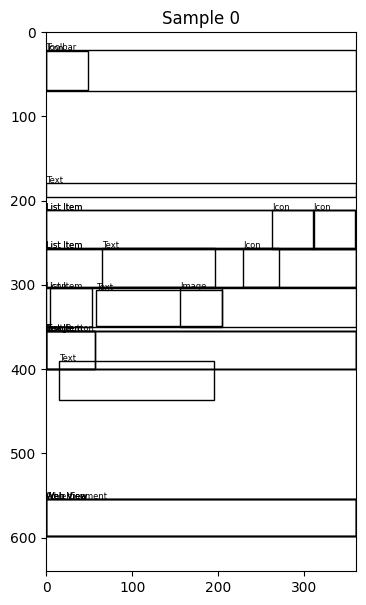

Sample 1: 25 elementos


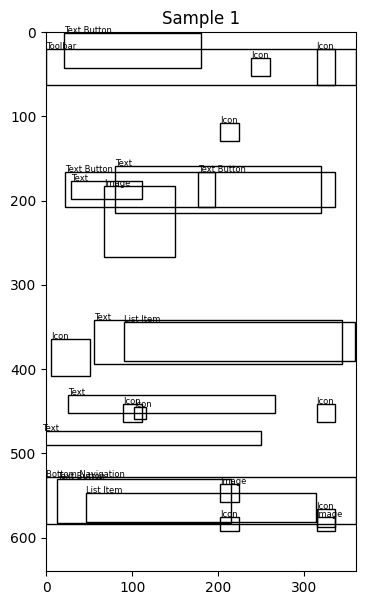

Sample 2: 25 elementos


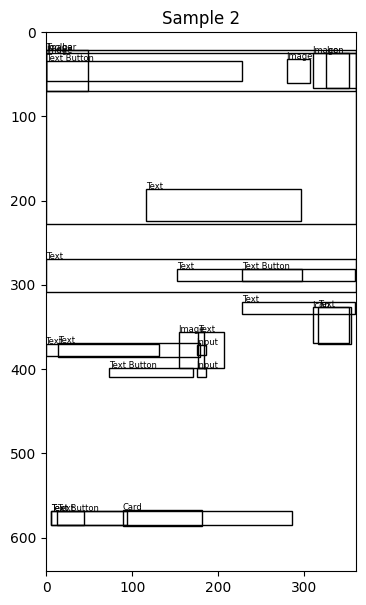

Sample 3: 25 elementos


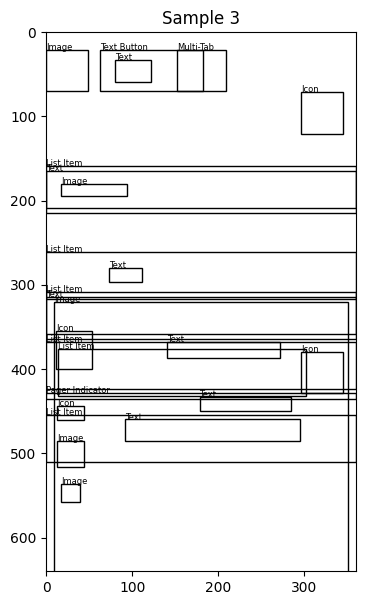

Sample 4: 25 elementos


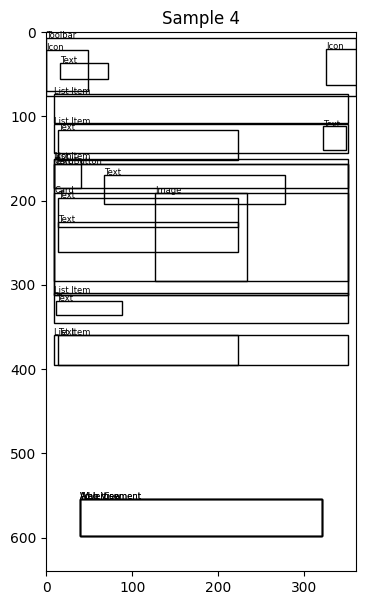

Sample 5: 25 elementos


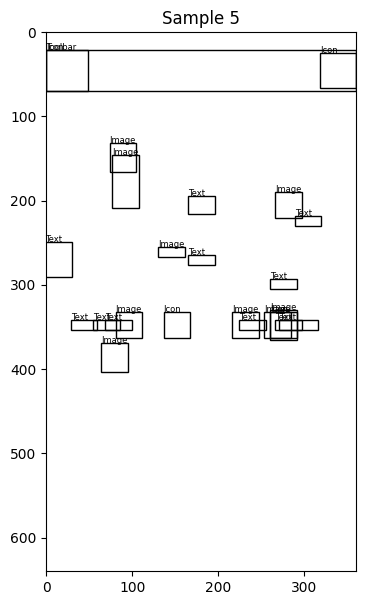

Sample 6: 25 elementos


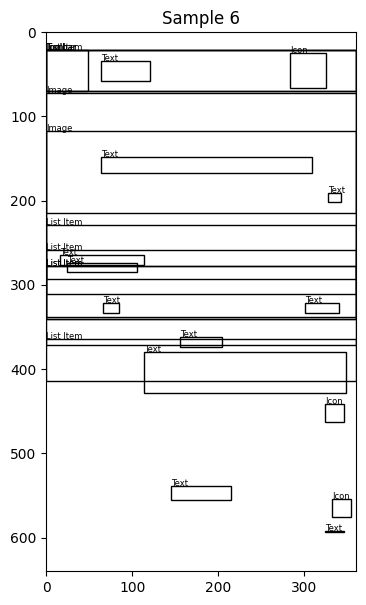

Sample 7: 25 elementos


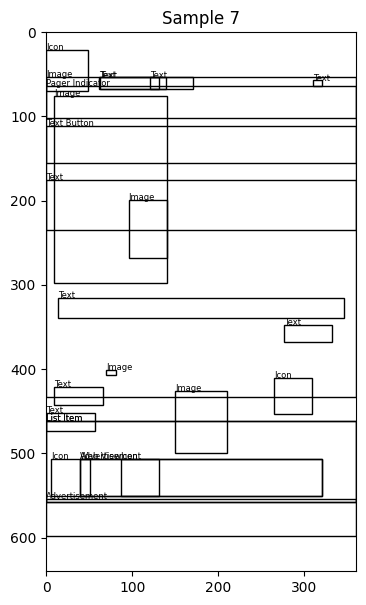

: 

In [19]:
samples = unconditional_sample(
    model, cfg, vocab_meta, batch_size=8,
    Qts_all=Qts_all, Qbars_all=Qbars_all,
)

for i in range(samples.size(0)):
    decoded = decode_layout(samples[i].cpu(), vocab_meta, id2cat, centroids)
    print(f"Sample {i}: {len(decoded)} elementos")
    render_layout(decoded, title=f"Sample {i}")

tokens_val shape: (6619, 25, 5)
Selected indices: [5238, 912, 204, 6074, 2253, 2006, 1828, 1143, 6033, 839, 5543, 6067, 4467, 712, 4837, 3456, 260, 244, 767, 1791]


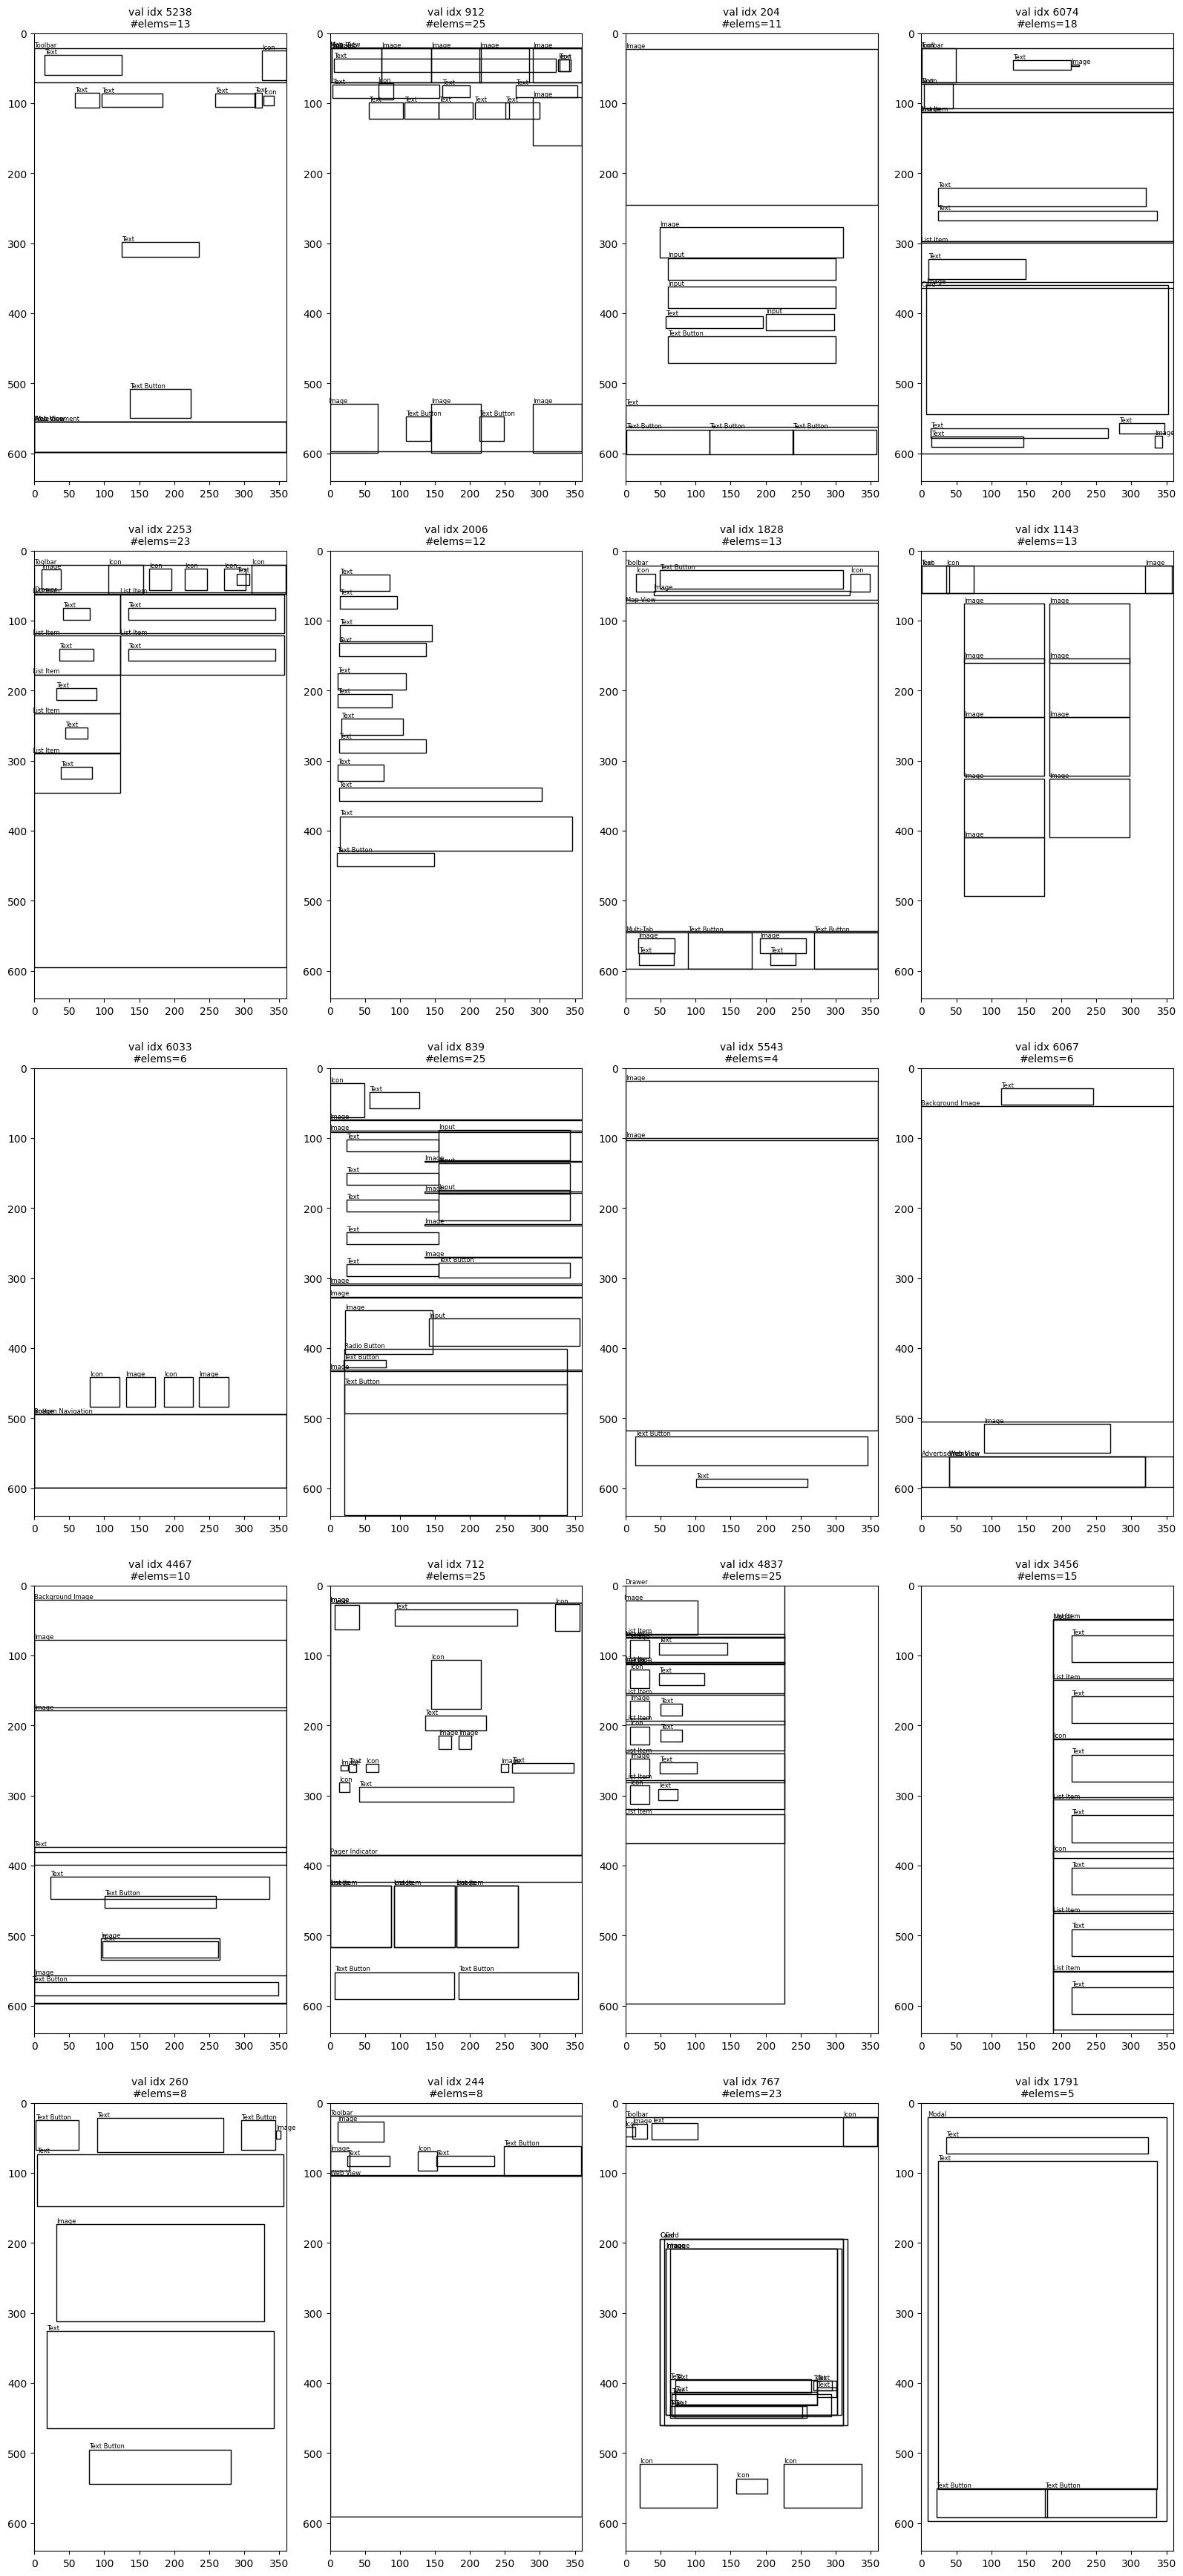

: 

In [20]:
import os
import json
import math
import random
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Config
# =========================================================
DATA_DIR = "/content/layoutdm_rico_tokens"
TOKENS_FILE = os.path.join(DATA_DIR, "tokens_val.pt")

CANVAS_W = 360
CANVAS_H = 640

NUM_SAMPLES = 20
RANDOM_SEED = 42
USE_RANDOM_SAMPLES = True   # True = aleatorias, False = primeras 20

# =========================================================
# Load artifacts
# =========================================================
with open(os.path.join(DATA_DIR, "vocab_meta.json"), "r", encoding="utf-8") as f:
    vocab_meta = json.load(f)

with open(os.path.join(DATA_DIR, "cat2id.json"), "r", encoding="utf-8") as f:
    cat2id = json.load(f)

id2cat = {int(v): k for k, v in cat2id.items()}

centroids = {
    "x": torch.load(os.path.join(DATA_DIR, "centroids_x.pt"), map_location="cpu"),
    "y": torch.load(os.path.join(DATA_DIR, "centroids_y.pt"), map_location="cpu"),
    "w": torch.load(os.path.join(DATA_DIR, "centroids_w.pt"), map_location="cpu"),
    "h": torch.load(os.path.join(DATA_DIR, "centroids_h.pt"), map_location="cpu"),
}

tokens_val = torch.load(TOKENS_FILE, map_location="cpu").long()

print("tokens_val shape:", tuple(tokens_val.shape))


# =========================================================
# Decode helpers
# =========================================================
def safe_centroid_lookup(centroid_tensor, idx):
    idx = int(idx)
    if idx < 0 or idx >= len(centroid_tensor):
        return None
    return float(centroid_tensor[idx])


def decode_layout(tokens_row, vocab_meta, id2cat, centroids):
    """
    tokens_row: [M, 5] => (c, x, y, w, h)
    return: list[dict]
    """
    decoded = []

    c_pad = int(vocab_meta["c"]["pad_id"])
    c_mask = int(vocab_meta["c"]["mask_id"])

    x_pad = int(vocab_meta["x"]["pad_id"])
    x_mask = int(vocab_meta["x"]["mask_id"])
    y_pad = int(vocab_meta["y"]["pad_id"])
    y_mask = int(vocab_meta["y"]["mask_id"])
    w_pad = int(vocab_meta["w"]["pad_id"])
    w_mask = int(vocab_meta["w"]["mask_id"])
    h_pad = int(vocab_meta["h"]["pad_id"])
    h_mask = int(vocab_meta["h"]["mask_id"])

    for row in tokens_row.tolist():
        c_id, x_id, y_id, w_id, h_id = [int(v) for v in row]

        # PAD row
        if c_id == c_pad:
            continue

        # skip MASK rows / invalid category
        if c_id == c_mask or c_id not in id2cat:
            continue

        # skip masked/padded geometry
        if x_id in (x_pad, x_mask) or y_id in (y_pad, y_mask) or w_id in (w_pad, w_mask) or h_id in (h_pad, h_mask):
            continue

        x = safe_centroid_lookup(centroids["x"], x_id)
        y = safe_centroid_lookup(centroids["y"], y_id)
        w = safe_centroid_lookup(centroids["w"], w_id)
        h = safe_centroid_lookup(centroids["h"], h_id)

        if None in (x, y, w, h):
            continue

        decoded.append({
            "class": id2cat[c_id],
            "x": x,
            "y": y,
            "w": w,
            "h": h,
        })

    return decoded


# =========================================================
# Render helpers
# =========================================================
def render_layout(ax, decoded, canvas_w=360, canvas_h=640, title=""):
    ax.set_xlim(0, canvas_w)
    ax.set_ylim(canvas_h, 0)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")

    for elem in decoded:
        cls = elem["class"]

        # normalized center-size -> pixel box
        x = elem["x"] * canvas_w
        y = elem["y"] * canvas_h
        w = elem["w"] * canvas_w
        h = elem["h"] * canvas_h

        # basic sanity guards
        if w <= 0 or h <= 0:
            continue

        x0 = x - w / 2
        y0 = y - h / 2

        rect = patches.Rectangle((x0, y0), w, h, fill=False, linewidth=1)
        ax.add_patch(rect)
        ax.text(x0, y0, cls, fontsize=6, va="bottom")

    ax.grid(False)


# =========================================================
# Pick 20 samples
# =========================================================
N = tokens_val.shape[0]
num = min(NUM_SAMPLES, N)

if USE_RANDOM_SAMPLES:
    random.seed(RANDOM_SEED)
    indices = random.sample(range(N), num)
else:
    indices = list(range(num))

print("Selected indices:", indices)


# =========================================================
# Render 20 samples in a grid
# =========================================================
cols = 4
rows = math.ceil(num / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 7))
axes = axes.flatten()

for i, idx in enumerate(indices):
    tokens_row = tokens_val[idx]   # [M, 5]
    decoded = decode_layout(tokens_row, vocab_meta, id2cat, centroids)
    render_layout(
        axes[i],
        decoded,
        canvas_w=CANVAS_W,
        canvas_h=CANVAS_H,
        title=f"val idx {idx}\n#elems={len(decoded)}"
    )

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

: 

In [21]:
def check_pad_tail(token_tensors, vocab_meta, num_samples=200):
    c_pad = vocab_meta["c"]["pad_id"]
    bad = []

    limit = min(num_samples, token_tensors.size(0))
    for i in range(limit):
        tokens = token_tensors[i]  # [M,5]
        valid = (tokens[:, 0] != c_pad).cpu()

        found_pad = False
        for j in range(tokens.size(0)):
            if not valid[j]:
                found_pad = True
            elif found_pad:
                bad.append(i)
                break

    if bad:
        print(f"Hay muestras con PAD intermedio. Ejemplos: {bad[:10]}")
    else:
        print("OK: en todas las muestras revisadas, PAD está solo al final.")

: 

In [22]:
tokens_train = torch.load(os.path.join(data_dir, f"tokens_{"train"}.pt"), map_location="cpu")

: 

In [23]:
check_pad_tail(tokens_train, vocab_meta, num_samples=1000)

OK: en todas las muestras revisadas, PAD está solo al final.


: 

In [24]:
def validate_shuffle_once(dataset, idx=0):
    c_pad = dataset.vocab_meta["c"]["pad_id"]
    x0 = dataset.x[idx].clone()

    x1 = dataset._shuffle_valid_elements(x0.clone())

    valid0 = (x0[:, 0] != c_pad)
    valid1 = (x1[:, 0] != c_pad)

    n0 = int(valid0.sum())
    n1 = int(valid1.sum())

    print(f"n_valid original: {n0}")
    print(f"n_valid shuffled: {n1}")

    assert n0 == n1, "Cambió el número de elementos reales"

    # comparar PAD tail
    assert torch.equal(x0[n0:], x1[n1:]), "La cola PAD cambió"

    # comparar contenido real ignorando orden
    real0 = x0[:n0]
    real1 = x1[:n1]

    def sort_rows(t):
        return t[torch.lexsort([
            t[:, 4], t[:, 3], t[:, 2], t[:, 1], t[:, 0]
        ])]

    # torch.lexsort no existe en muchas versiones, así que usamos Python
    real0_sorted = sorted(real0.tolist())
    real1_sorted = sorted(real1.tolist())

    assert real0_sorted == real1_sorted, "El shuffle corrompió elementos"

    print("OK: shuffle conserva contenido, mezcla reales y deja PAD al final.")

: 

In [25]:
train_ds = LayoutTokenDataset(tokens_train, vocab_meta, shuffle_elements=True)
validate_shuffle_once(train_ds, idx=0)
validate_shuffle_once(train_ds, idx=10)
validate_shuffle_once(train_ds, idx=100)

n_valid original: 25
n_valid shuffled: 25
OK: shuffle conserva contenido, mezcla reales y deja PAD al final.
n_valid original: 17
n_valid shuffled: 17
OK: shuffle conserva contenido, mezcla reales y deja PAD al final.
n_valid original: 6
n_valid shuffled: 6
OK: shuffle conserva contenido, mezcla reales y deja PAD al final.


: 

In [26]:
def inspect_shuffle_repeats(dataset, idx=0, repeats=5):
    c_pad = dataset.vocab_meta["c"]["pad_id"]
    base = dataset.x[idx].clone()
    n_valid = int((base[:, 0] != c_pad).sum())

    print("Original:")
    print(base[:n_valid])

    for r in range(repeats):
        sh = dataset._shuffle_valid_elements(base.clone())
        print(f"\nShuffle #{r+1}:")
        print(sh[:n_valid])

: 

In [27]:
inspect_shuffle_repeats(train_ds, idx=0, repeats=3)

Original:
tensor([[13, 34, 31, 56, 60],
        [21, 51, 58, 16, 13],
        [20, 34,  4, 51,  8],
        [11, 34, 10, 56, 16],
        [ 8,  9, 10,  7, 10],
        [20, 35, 10, 45,  5],
        [11, 34, 16, 56, 17],
        [ 9,  9, 16,  7, 10],
        [20, 35, 16, 45,  5],
        [11, 34, 22, 56, 17],
        [ 8,  9, 22,  7, 10],
        [20, 35, 22, 45,  5],
        [11, 34, 28, 56, 17],
        [ 8,  9, 28,  7, 10],
        [20, 35, 28, 45,  5],
        [ 8, 55, 28,  5,  6],
        [11, 34, 33, 56, 17],
        [ 8,  9, 33,  7, 10],
        [20, 35, 33, 45,  5],
        [11, 34, 39, 56, 17],
        [ 8,  9, 39,  7, 10],
        [20, 35, 39, 45,  5],
        [11, 34, 45, 56, 17],
        [ 8,  9, 45,  7, 10],
        [20, 35, 45, 45,  5]])

Shuffle #1:
tensor([[11, 34, 39, 56, 17],
        [ 8, 55, 28,  5,  6],
        [20, 34,  4, 51,  8],
        [11, 34, 28, 56, 17],
        [11, 34, 10, 56, 16],
        [11, 34, 45, 56, 17],
        [ 8,  9, 22,  7, 10],
        [20, 35,

: 

: 